# Bank Marketing Campaign Analysis & Classification

## Objective
Predict whether a bank customer will subscribe to a term deposit (`y`) using customer and campaign information.

### Project focus
- Data preprocessing
- Missing-value handling
- Skewness analysis and transformation
- Outlier treatment
- Correlation analysis
- Class-imbalance handling
- Decision Tree Classifier
- Random Forest Classifier
- F1-score based evaluation

> **Important:** This notebook uses the single Bank Marketing CSV dataset. The train/test split is created inside the notebook; separate train/test CSV files are not required.

## 1. Import Libraries

In [1]:
# Install imbalanced-learn if it is not already available
!pip -q install imbalanced-learn

In [2]:
import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, PowerTransformer
from sklearn.impute import SimpleImputer
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix
)

from imblearn.over_sampling import RandomOverSampler

warnings.filterwarnings("ignore")
np.random.seed(42)

## 2. Load the Dataset

Upload the CSV to Colab and make sure the filename below matches the uploaded file.

In [3]:
DATA_PATH = "/content/Bank Marketing Campaign_Data (1).csv"
if not os.path.exists(DATA_PATH):
    DATA_PATH = "/mnt/data/Bank Marketing Campaign_Data (1).csv"

# If the exact filename is different, automatically use the first CSV in /content.
if not os.path.exists(DATA_PATH):
    csv_files = [f for f in os.listdir("/content") if f.lower().endswith(".csv")]
    if not csv_files and os.path.exists("/mnt/data"):
        csv_files = [f for f in os.listdir("/mnt/data") if f.lower().endswith(".csv")]
        base_dir = "/mnt/data"
    else:
        base_dir = "/content"
    if not csv_files:
        raise FileNotFoundError("No CSV file found. Upload the Bank Marketing CSV first.")
    DATA_PATH = os.path.join(base_dir, csv_files[0])

df = pd.read_csv(DATA_PATH)

print("Dataset shape:", df.shape)
df.head()

Dataset shape: (45211, 18)


,Unnamed: 0,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,-1,0,unknown,no
1,1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,-1,0,unknown,no
2,2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,-1,0,unknown,no
3,3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,92,1,-1,0,unknown,no
4,4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,198,1,-1,0,unknown,no


## 3. Initial Data Understanding

In [4]:
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])
print("\nColumn names:")
print(df.columns.tolist())

print("\nData types:")
display(df.dtypes.to_frame("dtype"))

print("\nBasic statistics:")
display(df.describe(include="all").T)

Rows: 45211
Columns: 18

Column names:
['Unnamed: 0', 'age', 'job', 'marital', 'education', 'default', 'balance', 'housing', 'loan', 'contact', 'day', 'month', 'duration', 'campaign', 'pdays', 'previous', 'poutcome', 'y']

Data types:


,dtype
Unnamed: 0,int64
age,int64
job,object
marital,object
education,object
default,object
balance,int64
housing,object
loan,object
contact,object



Basic statistics:


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Unnamed: 0,45211.0,NaN,NaN,NaN,22605.0,13051.435847,0.0,11302.5,22605.0,33907.5,45210.0
age,45211.0,NaN,NaN,NaN,40.93621,10.618762,18.0,33.0,39.0,48.0,95.0
job,45211,12,blue-collar,9732,NaN,NaN,NaN,NaN,NaN,NaN,NaN
marital,45211,3,married,27214,NaN,NaN,NaN,NaN,NaN,NaN,NaN
education,45211,4,secondary,23202,NaN,NaN,NaN,NaN,NaN,NaN,NaN
default,45211,2,no,44396,NaN,NaN,NaN,NaN,NaN,NaN,NaN
balance,45211.0,NaN,NaN,NaN,1362.272058,3044.765829,-8019.0,72.0,448.0,1428.0,102127.0
housing,45211,2,yes,25130,NaN,NaN,NaN,NaN,NaN,NaN,NaN
loan,45211,2,no,37967,NaN,NaN,NaN,NaN,NaN,NaN,NaN
contact,45211,3,cellular,29285,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 4. Data Quality Checks

The dataset contains an index-like `Unnamed: 0` column, which does not carry useful predictive information, so it is removed.

In this dataset, several categorical fields use `unknown` to represent an unavailable/missing value. These values are treated as missing and later imputed using the most frequent category.

In [5]:
# Remove the CSV index column if it exists
if "Unnamed: 0" in df.columns:
    df = df.drop(columns=["Unnamed: 0"])

# Check duplicate rows
print("Duplicate rows:", df.duplicated().sum())

# Convert categorical 'unknown' values into missing values
categorical_cols = df.select_dtypes(include="object").columns.tolist()

for col in categorical_cols:
    if col != "y":
        df[col] = df[col].replace("unknown", np.nan)

print("\nMissing values after treating 'unknown' as missing:")
missing = df.isna().sum().sort_values(ascending=False)
display(missing[missing > 0].to_frame("missing_count"))

print("\nTarget distribution:")
display(df["y"].value_counts())

Duplicate rows: 0

Missing values after treating 'unknown' as missing:


,missing_count
poutcome,36959
contact,13020
education,1857
job,288



Target distribution:


,count
y,
no,39922
yes,5289


## 5. Missing-Value Analysis

,Missing Count,Missing Percentage
contact,13020,28.798301
education,1857,4.107407
job,288,0.637013
poutcome,36959,81.747805


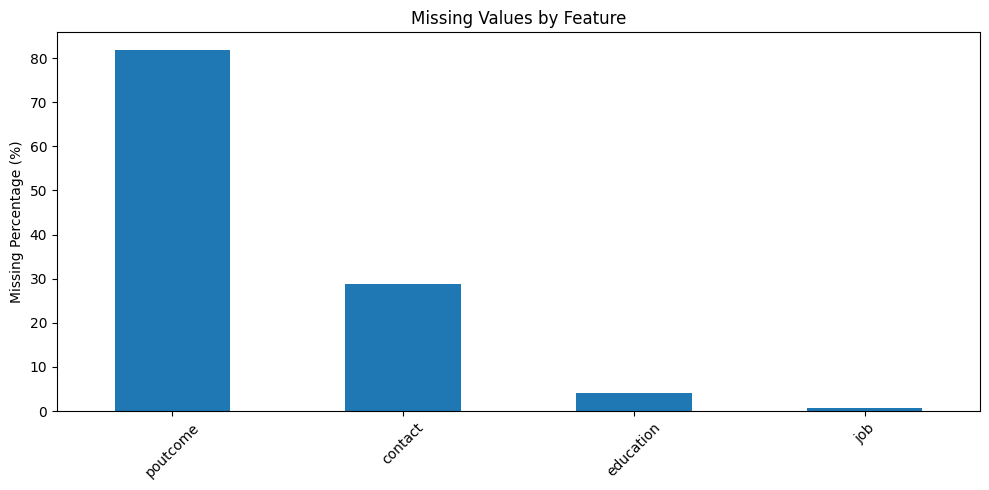

In [6]:
missing_pct = (df.isna().mean() * 100).sort_values(ascending=False)
missing_table = pd.DataFrame({
    "Missing Count": df.isna().sum(),
    "Missing Percentage": missing_pct
})
display(missing_table[missing_table["Missing Count"] > 0])

plt.figure(figsize=(10, 5))
missing_pct[missing_pct > 0].plot(kind="bar")
plt.title("Missing Values by Feature")
plt.ylabel("Missing Percentage (%)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## 6. Target Class Imbalance

The target is highly imbalanced: the majority of customers did not subscribe to a term deposit.

Because accuracy can look misleading on an imbalanced dataset, **F1-score, precision, recall, and ROC-AUC** are also reported.

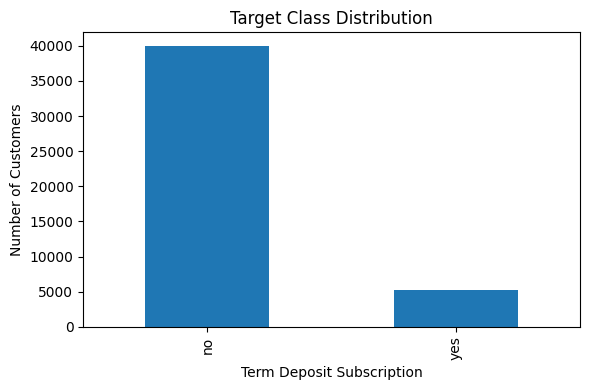

y
no     39922
yes     5289
Name: count, dtype: int64

Positive-class percentage: 11.7 %


In [7]:
target_counts = df["y"].value_counts()

plt.figure(figsize=(6, 4))
df["y"].value_counts().reindex(["no", "yes"]).plot(kind="bar")
plt.title("Target Class Distribution")
plt.xlabel("Term Deposit Subscription")
plt.ylabel("Number of Customers")
plt.tight_layout()
plt.show()

print(target_counts)
print("\nPositive-class percentage:", round((target_counts.get("yes", 0) / len(df)) * 100, 2), "%")

## 7. Skewness Analysis

,skewness
previous,41.846454
balance,8.360308
campaign,4.898650
duration,3.144318
pdays,2.615715
age,0.684818
day,0.093079


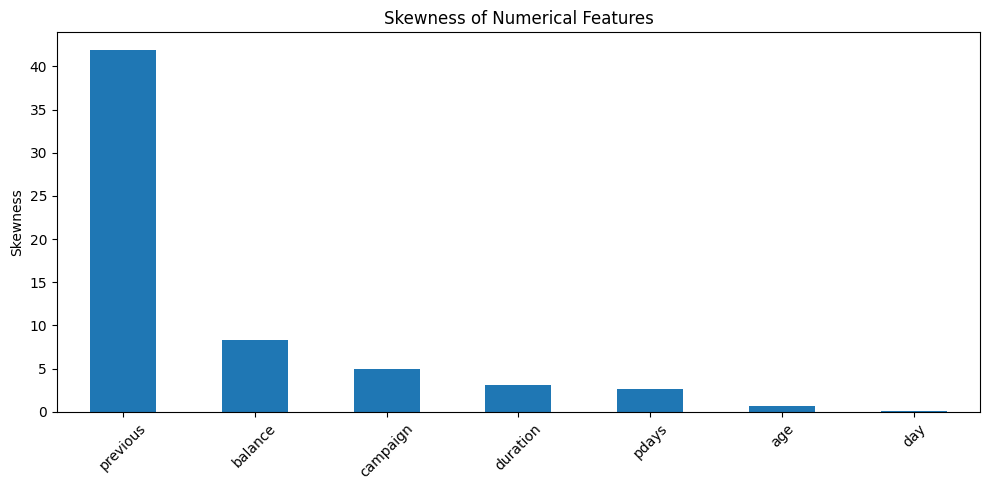

In [8]:
numeric_cols = df.select_dtypes(include=np.number).columns.tolist()

skewness = df[numeric_cols].skew().sort_values(ascending=False)
display(skewness.to_frame("skewness"))

plt.figure(figsize=(10, 5))
skewness.plot(kind="bar")
plt.title("Skewness of Numerical Features")
plt.ylabel("Skewness")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Highly skewed numerical variables can be difficult for some models. Here, a **Yeo-Johnson Power Transformation** is applied inside the preprocessing pipeline. It is fitted only on the training data to avoid data leakage.

## 8. Outlier Analysis

,Feature,Outlier Count,Outlier Percentage
6,previous,8257,18.26
5,pdays,8257,18.26
1,balance,4729,10.46
3,duration,3235,7.16
4,campaign,3064,6.78
0,age,487,1.08
2,day,0,0.00


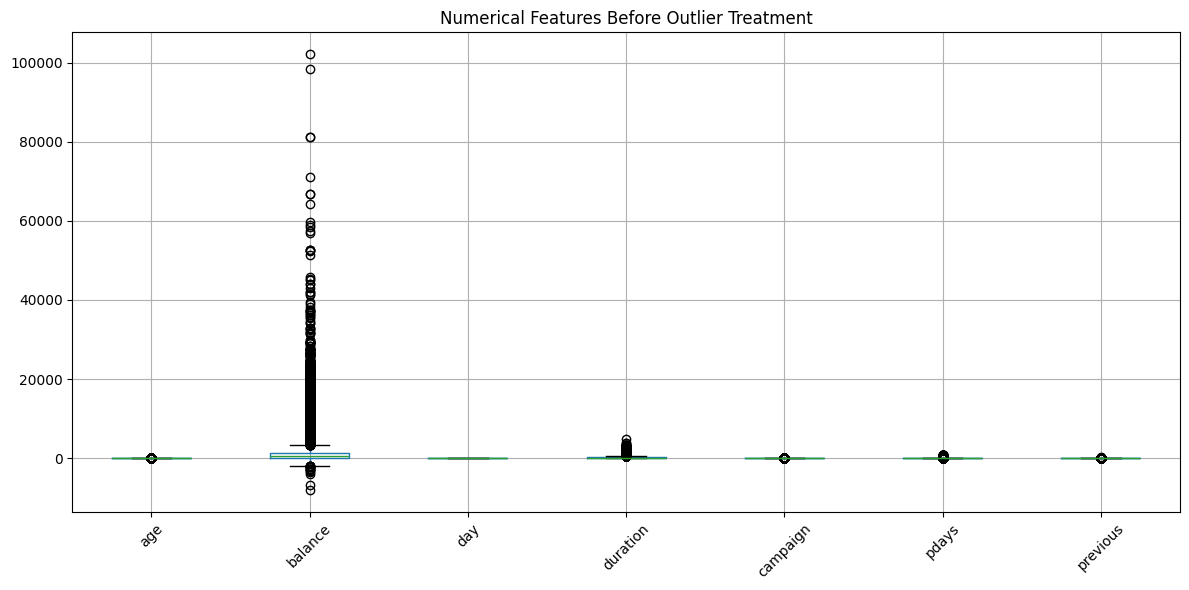

In [9]:
# IQR-based outlier counts before treatment
outlier_summary = []

for col in numeric_cols:
    q1 = df[col].quantile(0.25)
    q3 = df[col].quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    count = ((df[col] < lower) | (df[col] > upper)).sum()
    outlier_summary.append([col, count, round(count / len(df) * 100, 2)])

outlier_table = pd.DataFrame(
    outlier_summary,
    columns=["Feature", "Outlier Count", "Outlier Percentage"]
).sort_values("Outlier Count", ascending=False)

display(outlier_table)

plt.figure(figsize=(12, 6))
df[numeric_cols].boxplot(figsize=(12, 6))
plt.title("Numerical Features Before Outlier Treatment")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

For the modelling pipeline, numerical outliers are treated using **IQR clipping**. The clipping limits are learned from the training data only.

In [10]:
class IQRClipper(BaseEstimator, TransformerMixin):
    def __init__(self, multiplier=1.5):
        self.multiplier = multiplier

    def fit(self, X, y=None):
        X = pd.DataFrame(X)
        self.lower_ = X.quantile(0.25) - self.multiplier * (X.quantile(0.75) - X.quantile(0.25))
        self.upper_ = X.quantile(0.75) + self.multiplier * (X.quantile(0.75) - X.quantile(0.25))
        return self

    def transform(self, X):
        X = pd.DataFrame(X).copy()
        return X.clip(self.lower_, self.upper_, axis=1).to_numpy()

    def get_feature_names_out(self, input_features=None):
        return np.asarray(input_features, dtype=object)

## 9. Correlation Analysis

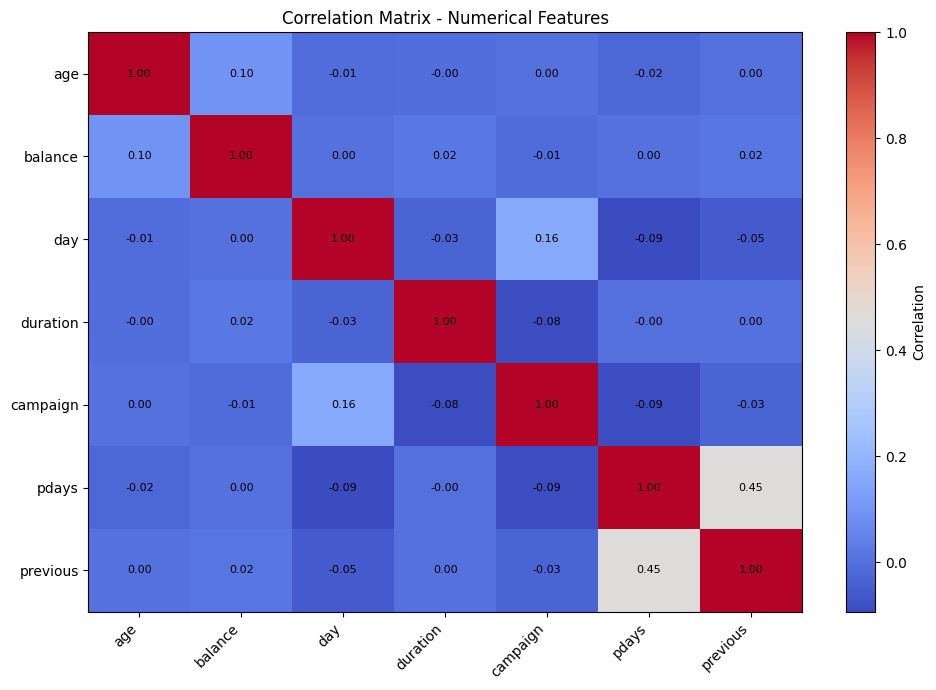

No numerical feature pairs have absolute correlation >= 0.80.


In [11]:
plt.figure(figsize=(10, 7))
corr = df[numeric_cols].corr()
plt.imshow(corr, cmap="coolwarm", aspect="auto")
plt.colorbar(label="Correlation")
plt.xticks(range(len(corr.columns)), corr.columns, rotation=45, ha="right")
plt.yticks(range(len(corr.columns)), corr.columns)
for i in range(len(corr.columns)):
    for j in range(len(corr.columns)):
        plt.text(j, i, f"{corr.iloc[i, j]:.2f}", ha="center", va="center", fontsize=8)
plt.title("Correlation Matrix - Numerical Features")
plt.tight_layout()
plt.show()

# Identify highly correlated numerical feature pairs
high_corr_pairs = []
for i in range(len(corr.columns)):
    for j in range(i + 1, len(corr.columns)):
        value = corr.iloc[i, j]
        if abs(value) >= 0.80:
            high_corr_pairs.append((corr.columns[i], corr.columns[j], value))

if high_corr_pairs:
    display(pd.DataFrame(high_corr_pairs, columns=["Feature 1", "Feature 2", "Correlation"]))
else:
    print("No numerical feature pairs have absolute correlation >= 0.80.")

## 10. Prepare Features and Target

`y = yes` is encoded as `1` and `y = no` as `0`.

The data is split **before** fitting preprocessing steps. This prevents information from the test set from leaking into training.

In [12]:
X = df.drop(columns=["y"])
y = df["y"].map({"no": 0, "yes": 1})

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))
print("\nTraining target distribution:")
print(y_train.value_counts())

Training samples: 36168
Testing samples: 9043

Training target distribution:
y
0    31937
1     4231
Name: count, dtype: int64


## 11. Preprocessing Pipeline

- Numerical features: median imputation → IQR outlier clipping → Yeo-Johnson transformation
- Categorical features: most-frequent imputation → one-hot encoding

In [13]:
numeric_features = X_train.select_dtypes(include=np.number).columns.tolist()
categorical_features = X_train.select_dtypes(include="object").columns.tolist()

numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("outlier_clipper", IQRClipper()),
    ("power_transform", PowerTransformer(method="yeo-johnson", standardize=True))
])

categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("one_hot", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
])

preprocessor = ColumnTransformer([
    ("numeric", numeric_pipeline, numeric_features),
    ("categorical", categorical_pipeline, categorical_features)
])

X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

print("Processed training shape:", X_train_processed.shape)
print("Processed testing shape:", X_test_processed.shape)

Processed training shape: (36168, 47)
Processed testing shape: (9043, 47)


## 12. Handle Class Imbalance

Random oversampling is applied **only to the training data**. The test set remains untouched so that evaluation represents unseen data.

Before oversampling:
y
0    31937
1     4231
Name: count, dtype: int64

After oversampling:
y
0    31937
1    31937
Name: count, dtype: int64


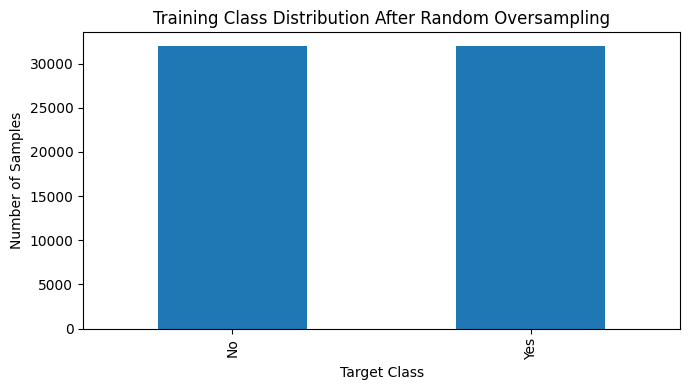

In [14]:
ros = RandomOverSampler(random_state=42)

X_train_balanced, y_train_balanced = ros.fit_resample(
    X_train_processed,
    y_train
)

print("Before oversampling:")
print(y_train.value_counts())

print("\nAfter oversampling:")
print(pd.Series(y_train_balanced).value_counts())

plt.figure(figsize=(7, 4))
pd.Series(y_train_balanced).value_counts().sort_index().plot(kind="bar")
plt.title("Training Class Distribution After Random Oversampling")
plt.xlabel("Target Class")
plt.ylabel("Number of Samples")
plt.xticks([0, 1], ["No", "Yes"])
plt.tight_layout()
plt.show()

## 13. Decision Tree Classifier

In [15]:
decision_tree = DecisionTreeClassifier(
    max_depth=8,
    min_samples_leaf=10,
    random_state=42
)

decision_tree.fit(X_train_balanced, y_train_balanced)

dt_pred = decision_tree.predict(X_test_processed)
dt_prob = decision_tree.predict_proba(X_test_processed)[:, 1]

dt_metrics = {
    "Accuracy": accuracy_score(y_test, dt_pred),
    "Precision": precision_score(y_test, dt_pred),
    "Recall": recall_score(y_test, dt_pred),
    "F1 Score": f1_score(y_test, dt_pred),
    "ROC-AUC": roc_auc_score(y_test, dt_prob)
}

display(pd.DataFrame([dt_metrics], index=["Decision Tree"]).round(4))

print(classification_report(
    y_test,
    dt_pred,
    target_names=["No", "Yes"]
))

,Accuracy,Precision,Recall,F1 Score,ROC-AUC
Decision Tree,0.7898,0.3386,0.8355,0.4819,0.8797


              precision    recall  f1-score   support

          No       0.97      0.78      0.87      7985
         Yes       0.34      0.84      0.48      1058

    accuracy                           0.79      9043
   macro avg       0.66      0.81      0.68      9043
weighted avg       0.90      0.79      0.82      9043



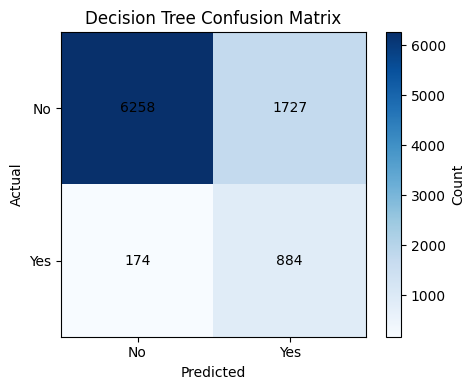

In [16]:
plt.figure(figsize=(5, 4))
plt.imshow(confusion_matrix(y_test, dt_pred), cmap="Blues")
plt.colorbar(label="Count")
plt.xticks([0, 1], ["No", "Yes"])
plt.yticks([0, 1], ["No", "Yes"])
cm_dt = confusion_matrix(y_test, dt_pred)
for i in range(2):
    for j in range(2):
        plt.text(j, i, cm_dt[i, j], ha="center", va="center")
plt.title("Decision Tree Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()

## 14. Random Forest Classifier

In [17]:
random_forest = RandomForestClassifier(
    n_estimators=300,
    min_samples_leaf=2,
    max_features="sqrt",
    random_state=42,
    n_jobs=-1
)

random_forest.fit(X_train_balanced, y_train_balanced)

rf_pred = random_forest.predict(X_test_processed)
rf_prob = random_forest.predict_proba(X_test_processed)[:, 1]

rf_metrics = {
    "Accuracy": accuracy_score(y_test, rf_pred),
    "Precision": precision_score(y_test, rf_pred),
    "Recall": recall_score(y_test, rf_pred),
    "F1 Score": f1_score(y_test, rf_pred),
    "ROC-AUC": roc_auc_score(y_test, rf_prob)
}

display(pd.DataFrame([rf_metrics], index=["Random Forest"]).round(4))

print(classification_report(
    y_test,
    rf_pred,
    target_names=["No", "Yes"]
))

,Accuracy,Precision,Recall,F1 Score,ROC-AUC
Random Forest,0.8919,0.5298,0.672,0.5925,0.9196


              precision    recall  f1-score   support

          No       0.95      0.92      0.94      7985
         Yes       0.53      0.67      0.59      1058

    accuracy                           0.89      9043
   macro avg       0.74      0.80      0.77      9043
weighted avg       0.91      0.89      0.90      9043



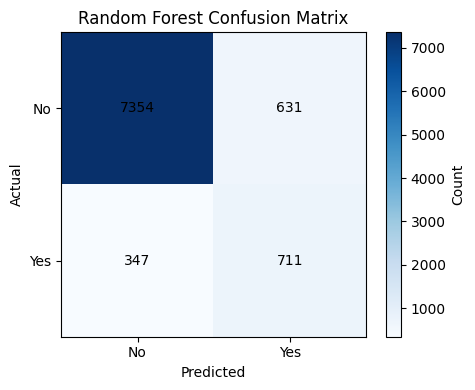

In [18]:
plt.figure(figsize=(5, 4))
plt.imshow(confusion_matrix(y_test, rf_pred), cmap="Blues")
plt.colorbar(label="Count")
plt.xticks([0, 1], ["No", "Yes"])
plt.yticks([0, 1], ["No", "Yes"])
cm_rf = confusion_matrix(y_test, rf_pred)
for i in range(2):
    for j in range(2):
        plt.text(j, i, cm_rf[i, j], ha="center", va="center")
plt.title("Random Forest Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()

## 15. Compare Decision Tree and Random Forest

,Accuracy,Precision,Recall,F1 Score,ROC-AUC
Decision Tree,0.7898,0.3386,0.8355,0.4819,0.8797
Random Forest,0.8919,0.5298,0.6720,0.5925,0.9196


<Figure size 800x500 with 0 Axes>

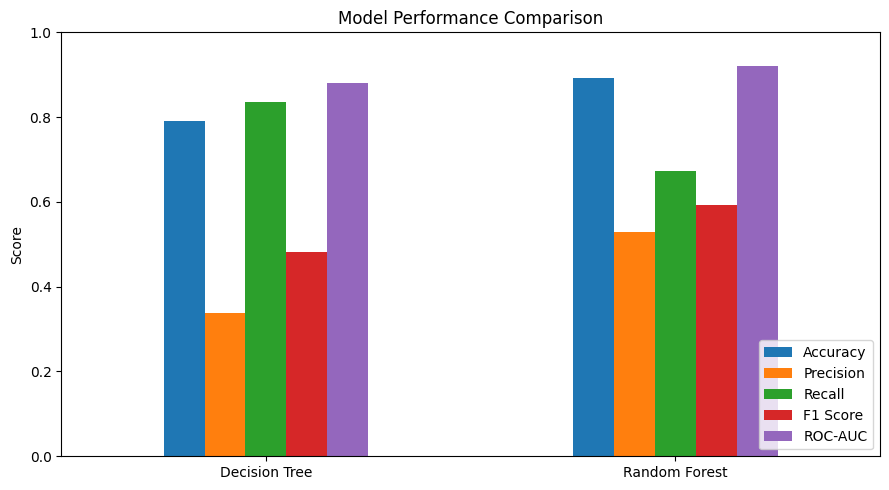

In [19]:
comparison = pd.DataFrame(
    [dt_metrics, rf_metrics],
    index=["Decision Tree", "Random Forest"]
).round(4)

display(comparison)

plt.figure(figsize=(8, 5))
comparison[["Accuracy", "Precision", "Recall", "F1 Score", "ROC-AUC"]].plot(kind="bar", figsize=(9, 5))
plt.title("Model Performance Comparison")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.xticks(rotation=0)
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

## 16. Random Forest Feature Importance

,Feature,Importance
3,numeric__duration,0.379275
0,numeric__age,0.078857
1,numeric__balance,0.078446
2,numeric__day,0.071177
46,categorical__poutcome_success,0.038962
44,categorical__poutcome_failure,0.035757
4,numeric__campaign,0.033494
26,categorical__housing_no,0.021440
27,categorical__housing_yes,0.020532
40,categorical__month_may,0.015708


<Figure size 1000x600 with 0 Axes>

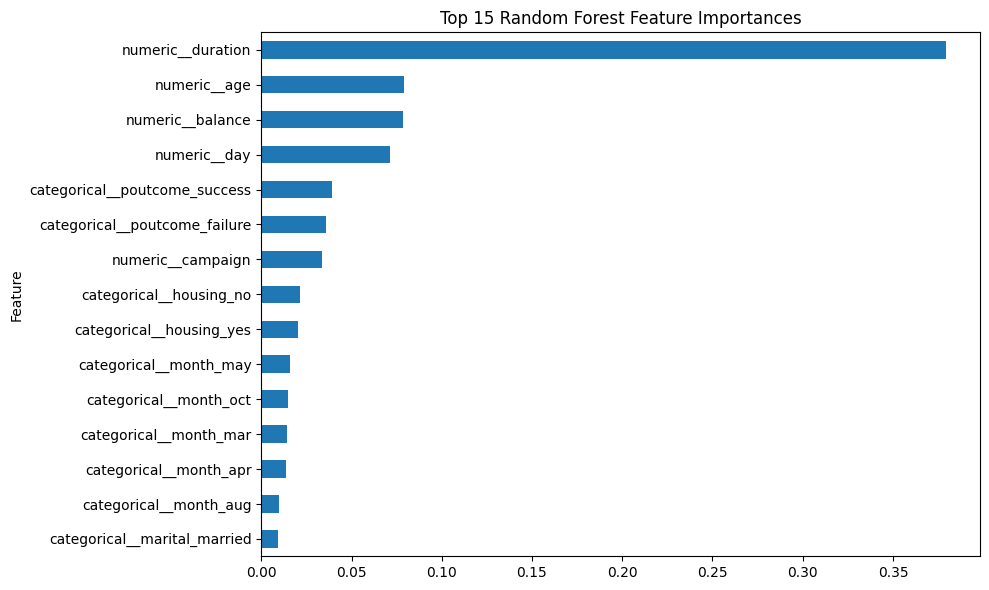

In [20]:
feature_names = preprocessor.get_feature_names_out()

rf_importance = pd.DataFrame({
    "Feature": feature_names,
    "Importance": random_forest.feature_importances_
}).sort_values("Importance", ascending=False)

display(rf_importance.head(15))

plt.figure(figsize=(10, 6))
rf_importance.head(15).sort_values("Importance").plot(kind="barh", x="Feature", y="Importance", legend=False, figsize=(10, 6))
plt.title("Top 15 Random Forest Feature Importances")
plt.tight_layout()
plt.show()

## 17. Final Project Summary

This project:
1. Loaded and inspected the Bank Marketing dataset.
2. Removed the unnecessary CSV index column.
3. Treated `unknown` categorical values as missing and imputed missing values.
4. Analysed skewness and applied a Yeo-Johnson transformation to numerical variables.
5. Identified and treated numerical outliers using IQR clipping.
6. Analysed correlations between numerical features.
7. Created training and testing sets from the single CSV using a stratified split.
8. Addressed class imbalance on the training set using Random Oversampling.
9. Trained and evaluated a Decision Tree classifier.
10. Trained and evaluated a Random Forest classifier.
11. Compared the models using accuracy, precision, recall, F1-score and ROC-AUC.

### Resume alignment
The notebook directly supports the project description:
- **Data preprocessing:** missing values, skewness, outliers, correlation and class imbalance.
- **Models:** Decision Tree and Random Forest.

**Do not hard-code a claimed F1-score into the notebook. Use the F1-score printed by the final evaluation after running the notebook on your actual dataset.**